# 交易策略对比分析

使用测试脚本中的最优配置，计算和可视化 Long Only、Sign(R) 和 MACD 三个策略的累积收益率对比

## Section 1: 导入必需的库

In [13]:
%pip install -q matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# 配置 matplotlib 中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 项目根目录路径（用于数据加载）
ROOT = Path('/Users/ladymie/Documents/GitHub/IEOR4733_Project')
# 输出目录（保存图表）
OUTPUT_DIR = Path.cwd()
sys.path.insert(0, str(ROOT))

# 导入基础函数
from data_loader import load_clc_full
from config import ASSET_CLASSES, BP, TRADING_DAYS, SIGN_LOOKBACK, EXCLUDED_CONTRACTS, SOURCE_OVERRIDES
from metrics import compute_metrics, max_drawdown_from_path, cagr_from_path

# 设置绘图风格
sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

print("✅ 所有库导入成功")

✅ 所有库导入成功


## Section 2: 导入各策略的最优配置和计算函数

In [43]:
# 导入各策略的最优配置（来自测试脚本）
sys.path.insert(0, str(ROOT / 'tests'))
sys.path.insert(0, str(ROOT / 'tests_MACD'))
sys.path.insert(0, str(ROOT / 'tests_Signr'))

try:
    import frontier_40plus_enumeration as fe_long
    LONG_OVERRIDES = fe_long.LEGACY_EXPERIMENTAL_OVERRIDES_LONG
    LONG_EXCLUDED = fe_long.LEGACY_EXPERIMENTAL_EXCLUDED_LONG
except ImportError as e:
    print(f"⚠️  无法导入 Long 配置: {e}")
    LONG_OVERRIDES = SOURCE_OVERRIDES
    LONG_EXCLUDED = EXCLUDED_CONTRACTS

try:
    import frontier_40plus_enumeration_macd as fe_macd
    MACD_OVERRIDES = fe_macd.LEGACY_EXPERIMENTAL_OVERRIDES_MACD
    MACD_EXCLUDED = fe_macd.LEGACY_EXPERIMENTAL_EXCLUDED_MACD
except ImportError as e:
    print(f"⚠️  无法导入 MACD 配置: {e}")
    MACD_OVERRIDES = SOURCE_OVERRIDES
    MACD_EXCLUDED = EXCLUDED_CONTRACTS

try:
    import frontier_40plus_enumeration_signr as fe_signr
    SIGNR_OVERRIDES = fe_signr.LEGACY_EXPERIMENTAL_OVERRIDES_SIGNR
    SIGNR_EXCLUDED = fe_signr.LEGACY_EXPERIMENTAL_EXCLUDED_SIGNR
except ImportError as e:
    print(f"⚠️  无法导入 Sign(R) 配置: {e}")
    SIGNR_OVERRIDES = SOURCE_OVERRIDES
    SIGNR_EXCLUDED = EXCLUDED_CONTRACTS

# 导入计算函数
from baseline_run import load_contracts, compute_portfolio_returns
import pandas as pd

# 参数设置
DEFAULT_SIGMA_TGT = 0.063
# 论文 Table 3 测试期间（2016-2019）
# 完整历史期间见 config.py（2011-01-01 ~ 2019-12-31）
TEST_START = '2011-01-01'
TEST_END = '2019-01-01'

ASSET_CLASSES_LIST = ['Commodity', 'Equity Index', 'Fixed Income', 'Forex']

def calculate_strategy_returns_by_asset(strat_name, overrides=None, excluded=None):
    """按资产类别分别计算策略的累积收益率
    
    返回字典格式：
    {
        'Commodity': (dates, wealth_path),
        'Equity Index': (dates, wealth_path),
        'Fixed Income': (dates, wealth_path),
        'FX': (dates, wealth_path),
        'All': (dates, wealth_path)
    }
    其中 wealth_path 是累积财富序列：W_t = 1 + cumsum(R_t)
    dates 是对应的日期数组
    """
    if overrides is None:
        overrides = {'Long': LONG_OVERRIDES, 'Sign(R)': SIGNR_OVERRIDES, 'MACD': MACD_OVERRIDES}.get(strat_name, SOURCE_OVERRIDES)
    if excluded is None:
        excluded = {'Long': LONG_EXCLUDED, 'Sign(R)': SIGNR_EXCLUDED, 'MACD': MACD_EXCLUDED}.get(strat_name, EXCLUDED_CONTRACTS)
    
    results = {}
    all_contracts = []
    all_dates = None
    
    # 按资产类别分别计算
    for ac_name in ASSET_CLASSES_LIST:
        raw = load_contracts(ac_name, TEST_START, TEST_END, excluded, overrides)
        if raw:
            port_returns = compute_portfolio_returns(raw, strat_name, DEFAULT_SIGMA_TGT)
            wealth = 1.0 + np.cumsum(port_returns)
            
            # 从合约数据中提取日期
            if raw and hasattr(raw[0], 'dates'):
                dates = raw[0].dates
            elif raw and hasattr(raw[0], 'index'):
                dates = raw[0].index
            else:
                # 如果无法提取日期，使用交易日索引
                dates = pd.date_range(start=TEST_START, periods=len(wealth), freq='B')
            
            results[ac_name] = (dates, wealth)
            all_contracts.extend(raw)
            # 保存第一个资产的日期作为基准（用于 All 资产）
            if all_dates is None:
                all_dates = dates
        else:
            results[ac_name] = (None, None)
    
    # 计算 All（所有资产合并）
    if all_contracts:
        port_returns_all = compute_portfolio_returns(all_contracts, strat_name, DEFAULT_SIGMA_TGT)
        wealth_all = 1.0 + np.cumsum(port_returns_all)
        # 使用全部合约的日期（如果有的话）
        if all_contracts and hasattr(all_contracts[0], 'dates'):
            dates_all = all_contracts[0].dates
        else:
            dates_all = pd.date_range(start=TEST_START, periods=len(wealth_all), freq='B')
        results['All'] = (dates_all, wealth_all)
    else:
        results['All'] = (None, None)
    
    return results

print("✅ 已加载各策略的最优配置")

✅ 已加载各策略的最优配置


## Section 3: 计算三个策略的累积收益率

In [44]:
print("🔄 正在按资产类别计算三个策略的累积收益率...")
print(f"测试期间: {TEST_START} 至 {TEST_END}\n")
print("=" * 80)

# 计算每个策略在各资产类别上的结果
strategies_results = {}

# 1. Long Only
print("计算 Long Only 策略...")
long_results = calculate_strategy_returns_by_asset('Long', LONG_OVERRIDES, LONG_EXCLUDED)
strategies_results['Long Only'] = long_results
for asset, (dates, wealth) in long_results.items():
    status = f"✅ ({len(wealth)} 个交易日)" if wealth is not None else "⚠️ 加载失败"
    print(f"  • {asset:20s} {status}")

# 2. Sign(R)
print("\n计算 Sign(R) 策略...")
signr_results = calculate_strategy_returns_by_asset('Sign(R)', SIGNR_OVERRIDES, SIGNR_EXCLUDED)
strategies_results['Sign(R)'] = signr_results
for asset, (dates, wealth) in signr_results.items():
    status = f"✅ ({len(wealth)} 个交易日)" if wealth is not None else "⚠️ 加载失败"
    print(f"  • {asset:20s} {status}")

# 3. MACD
print("\n计算 MACD 策略...")
macd_results = calculate_strategy_returns_by_asset('MACD', MACD_OVERRIDES, MACD_EXCLUDED)
strategies_results['MACD'] = macd_results
for asset, (dates, wealth) in macd_results.items():
    status = f"✅ ({len(wealth)} 个交易日)" if wealth is not None else "⚠️ 加载失败"
    print(f"  • {asset:20s} {status}")

print("=" * 80)
print("✅ 所有策略计算完成")

🔄 正在按资产类别计算三个策略的累积收益率...
测试期间: 2011-01-01 至 2019-01-01

计算 Long Only 策略...
  • Commodity            ✅ (2015 个交易日)
  • Equity Index         ✅ (2064 个交易日)
  • Fixed Income         ✅ (2063 个交易日)
  • Forex                ✅ (2070 个交易日)
  • All                  ✅ (2071 个交易日)

计算 Sign(R) 策略...
  • Commodity            ✅ (2015 个交易日)
  • Equity Index         ✅ (2064 个交易日)
  • Fixed Income         ✅ (2063 个交易日)
  • Forex                ✅ (2070 个交易日)
  • All                  ✅ (2071 个交易日)

计算 MACD 策略...
  • Commodity            ✅ (2015 个交易日)
  • Equity Index         ✅ (2064 个交易日)
  • Fixed Income         ✅ (2063 个交易日)
  • Forex                ✅ (2070 个交易日)
  • All                  ✅ (2071 个交易日)
✅ 所有策略计算完成


## Section 4: 可视化累积收益率对比

📊 生成论文风格的对比图表（5个资产类别 × 3个策略）...



/var/folders/15/pzbtkkl13ll1zl7klhbsnznw0000gn/T/ipykernel_51360/289629550.py:69: UserWarning: Glyph 26085 (\N{CJK UNIFIED IDEOGRAPH-65E5}) missing from font(s) Arial.
  plt.tight_layout(rect=[0, 0, 1, 0.98])
/var/folders/15/pzbtkkl13ll1zl7klhbsnznw0000gn/T/ipykernel_51360/289629550.py:69: UserWarning: Glyph 26399 (\N{CJK UNIFIED IDEOGRAPH-671F}) missing from font(s) Arial.
  plt.tight_layout(rect=[0, 0, 1, 0.98])
/var/folders/15/pzbtkkl13ll1zl7klhbsnznw0000gn/T/ipykernel_51360/289629550.py:69: UserWarning: Glyph 32047 (\N{CJK UNIFIED IDEOGRAPH-7D2F}) missing from font(s) Arial.
  plt.tight_layout(rect=[0, 0, 1, 0.98])
/var/folders/15/pzbtkkl13ll1zl7klhbsnznw0000gn/T/ipykernel_51360/289629550.py:69: UserWarning: Glyph 31215 (\N{CJK UNIFIED IDEOGRAPH-79EF}) missing from font(s) Arial.
  plt.tight_layout(rect=[0, 0, 1, 0.98])
/var/folders/15/pzbtkkl13ll1zl7klhbsnznw0000gn/T/ipykernel_51360/289629550.py:69: UserWarning: Glyph 36130 (\N{CJK UNIFIED IDEOGRAPH-8D22}) missing from font(s) Ari

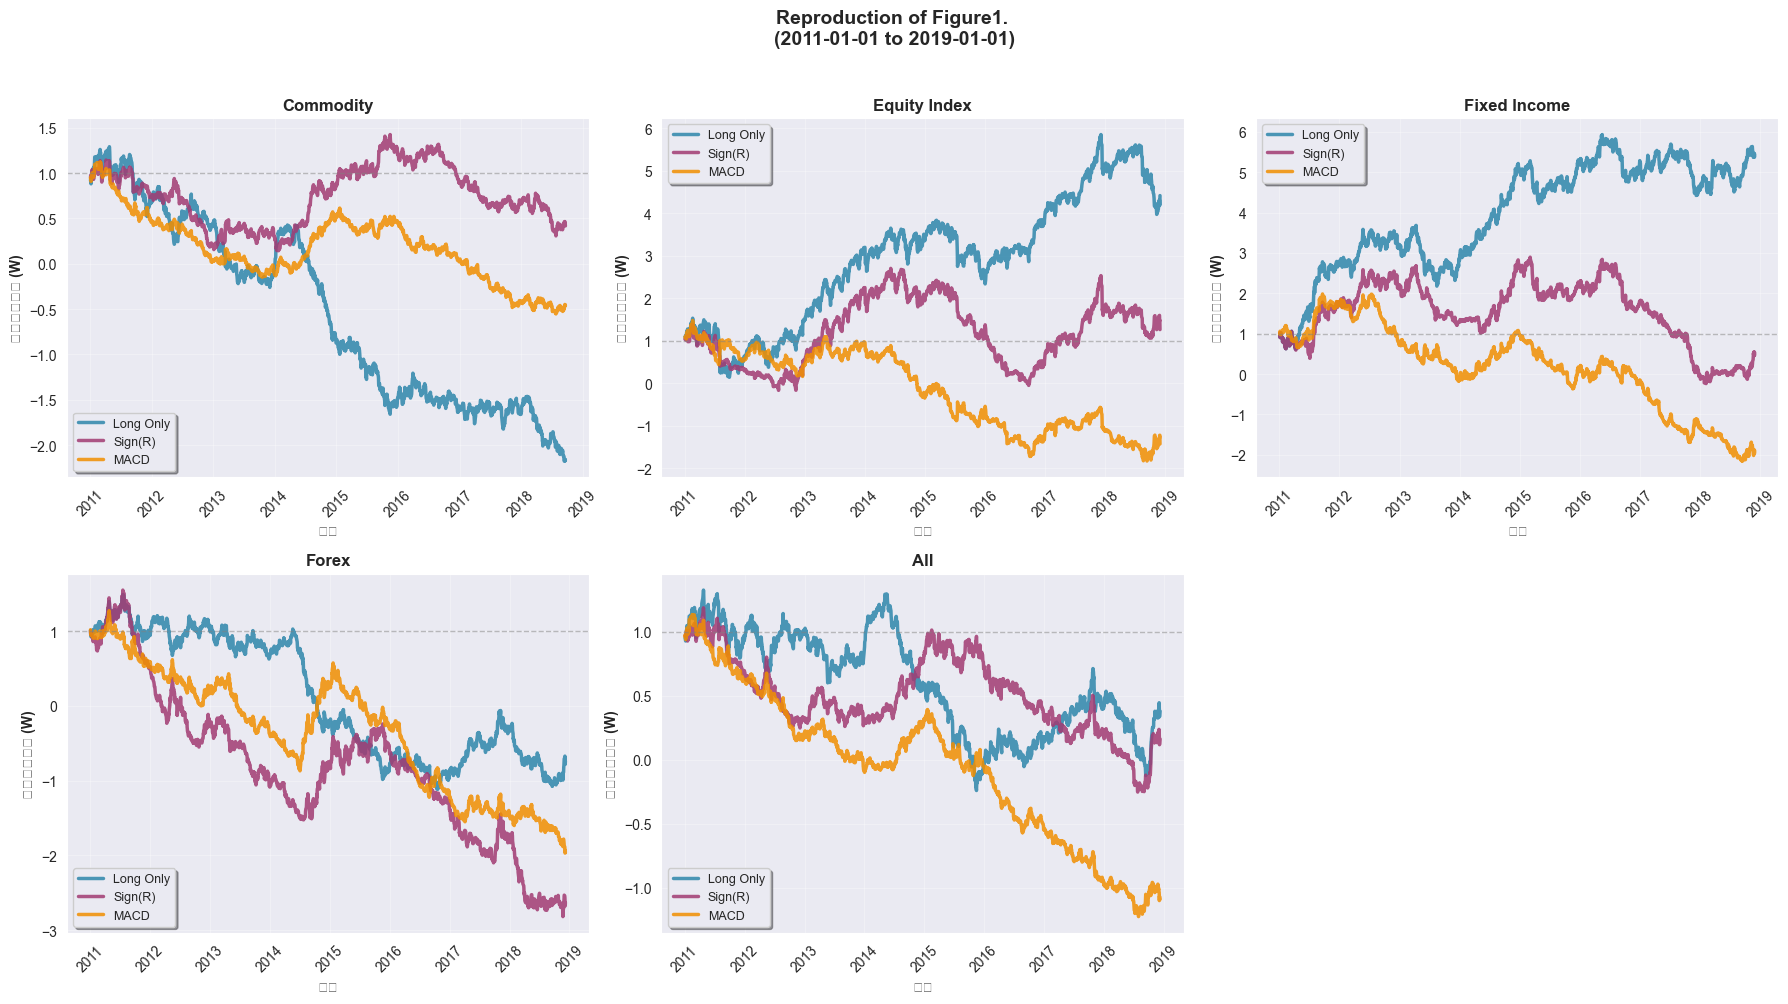

✅ 图表已保存为 strategies_by_asset_class.png


In [47]:
print("📊 生成论文风格的对比图表（5个资产类别 × 3个策略）...\n")

# 定义资产类别和对应的颜色
asset_order = ASSET_CLASSES_LIST + ['All']
strategy_colors = {
    'Long Only': '#2E86AB',
    'Sign(R)': '#A23B72',
    'MACD': '#F18F01'
}

# 创建 2x3 的子图布局（5张图 + 留白）
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, asset in enumerate(asset_order):
    ax = axes[idx]
    
    # 收集该资产类别的所有策略数据
    valid_data = {}
    for strategy, results in strategies_results.items():
        dates, wealth = results.get(asset, (None, None))
        if wealth is not None:
            valid_data[strategy] = (dates, wealth)
    
    if not valid_data:
        ax.text(0.5, 0.5, f'❌ {asset}\n数据不可用', 
                ha='center', va='center', fontsize=12, 
                transform=ax.transAxes, color='red')
        ax.set_title(f'{asset}', fontsize=12, fontweight='bold')
        continue
    
    # 对齐所有策略的长度
    min_len = min(len(wealth) for _, wealth in valid_data.values())
    
    # 绘制三条线
    for strategy, (dates, wealth) in valid_data.items():
        # 对齐日期和财富数据
        if dates is not None and len(dates) >= min_len:
            aligned_dates = dates[:min_len]
        else:
            aligned_dates = np.arange(min_len)
        
        ax.plot(aligned_dates, wealth[:min_len], 
                label=strategy, 
                linewidth=2.5, 
                color=strategy_colors[strategy], 
                alpha=0.85)
    
    # 设置坐标轴标签和标题
    ax.set_xlabel('日期', fontsize=10, fontweight='bold')
    ax.set_ylabel('累积财富倍数 (W)', fontsize=10, fontweight='bold')
    ax.set_title(f'{asset}', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best', fontsize=9, frameon=True, shadow=True)
    ax.axhline(y=1.0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
    
    # 旋转 x 轴标签以便阅读（仅当使用日期时）
    if isinstance(valid_data[list(valid_data.keys())[0]][0], (pd.DatetimeIndex, np.ndarray)):
        if hasattr(valid_data[list(valid_data.keys())[0]][0], '__iter__') and len(valid_data[list(valid_data.keys())[0]][0]) > 0:
            if isinstance(valid_data[list(valid_data.keys())[0]][0][0], (pd.Timestamp, np.datetime64)):
                ax.tick_params(axis='x', rotation=45)

# 隐藏多余的子图
for idx in range(len(asset_order), len(axes)):
    axes[idx].axis('off')

plt.suptitle(f'Reproduction of Figure1. \n({TEST_START} to {TEST_END})', 
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig(str(OUTPUT_DIR / 'strategies_by_asset_class.png'), dpi=300, bbox_inches='tight')
plt.show()

print("✅ 图表已保存为 strategies_by_asset_class.png")

## Section 5: 使用 baseline.py 默认配置计算策略（不含优化）

In [48]:
print("🔄 正在计算基线版本（使用默认配置）的策略...\n")

# 使用默认的 SOURCE_OVERRIDES 和 EXCLUDED_CONTRACTS
default_overrides = SOURCE_OVERRIDES
default_excluded = EXCLUDED_CONTRACTS

# 计算基线版本的三个策略
baseline_results = {}

print("计算基线版本 Long Only...")
baseline_results['Long Only'] = calculate_strategy_returns_by_asset('Long', default_overrides, default_excluded)

print("计算基线版本 Sign(R)...")
baseline_results['Sign(R)'] = calculate_strategy_returns_by_asset('Sign(R)', default_overrides, default_excluded)

print("计算基线版本 MACD...")
baseline_results['MACD'] = calculate_strategy_returns_by_asset('MACD', default_overrides, default_excluded)

print("\n✅ 基线版本计算完成")

🔄 正在计算基线版本（使用默认配置）的策略...

计算基线版本 Long Only...
计算基线版本 Sign(R)...
计算基线版本 MACD...

✅ 基线版本计算完成


## Section 6: 优化 vs 基线版本的性能对比

📊 绘制优化配置 vs 基线配置的对比图表...



/var/folders/15/pzbtkkl13ll1zl7klhbsnznw0000gn/T/ipykernel_51360/1208857070.py:64: UserWarning: Glyph 26085 (\N{CJK UNIFIED IDEOGRAPH-65E5}) missing from font(s) Arial.
  plt.tight_layout(rect=[0, 0, 1, 0.96])
/var/folders/15/pzbtkkl13ll1zl7klhbsnznw0000gn/T/ipykernel_51360/1208857070.py:64: UserWarning: Glyph 26399 (\N{CJK UNIFIED IDEOGRAPH-671F}) missing from font(s) Arial.
  plt.tight_layout(rect=[0, 0, 1, 0.96])
/var/folders/15/pzbtkkl13ll1zl7klhbsnznw0000gn/T/ipykernel_51360/1208857070.py:64: UserWarning: Glyph 32047 (\N{CJK UNIFIED IDEOGRAPH-7D2F}) missing from font(s) Arial.
  plt.tight_layout(rect=[0, 0, 1, 0.96])
/var/folders/15/pzbtkkl13ll1zl7klhbsnznw0000gn/T/ipykernel_51360/1208857070.py:64: UserWarning: Glyph 31215 (\N{CJK UNIFIED IDEOGRAPH-79EF}) missing from font(s) Arial.
  plt.tight_layout(rect=[0, 0, 1, 0.96])
/var/folders/15/pzbtkkl13ll1zl7klhbsnznw0000gn/T/ipykernel_51360/1208857070.py:64: UserWarning: Glyph 36130 (\N{CJK UNIFIED IDEOGRAPH-8D22}) missing from font(s

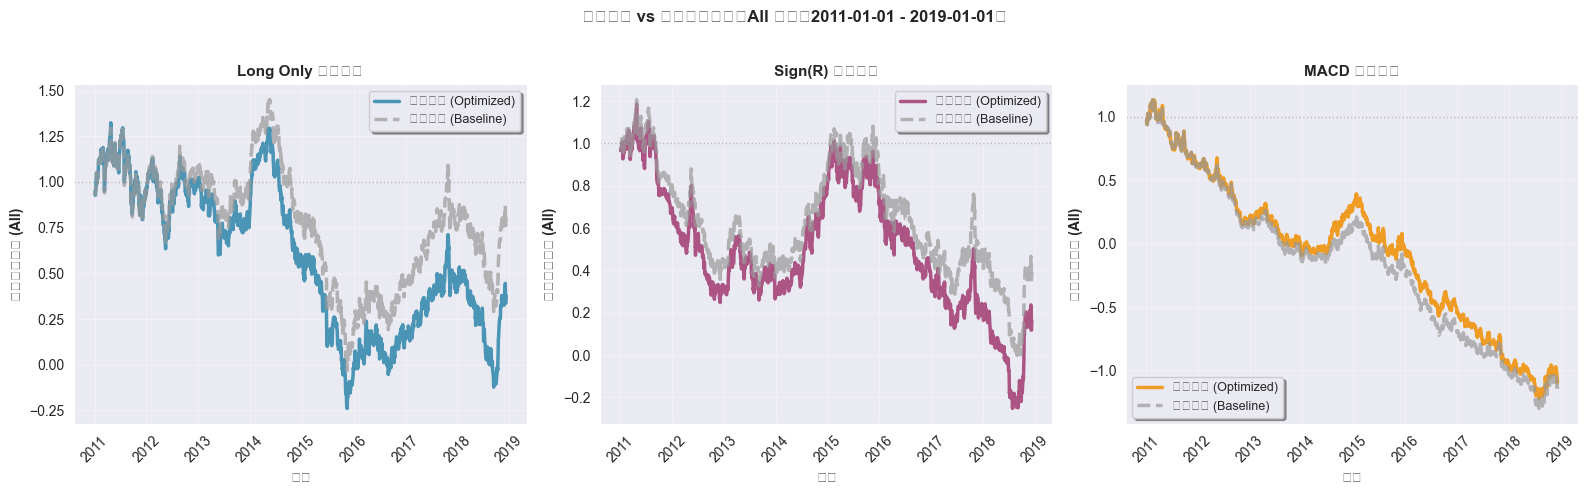

✅ 对比图表已保存为 strategies_optimized_vs_baseline.png

优化配置 vs 基线配置 — All 资产性能对比
 Strategy 优化总收益 (%) 基线总收益 (%) 改进 (pp) 优化年化 (%) 基线年化 (%) 优化波动率 (%) 基线波动率 (%)
Long Only    -61.94    -19.40  -42.54   -11.09    -2.59   1602.61    762.08
  Sign(R)    -83.68    -60.74  -22.94   -19.80   -10.75    825.61   2396.09
     MACD   -208.85   -214.52    5.67      nan      nan  15685.71   2763.42

✅ 详细对比已保存为 strategies_optimized_vs_baseline_analysis.csv


/var/folders/15/pzbtkkl13ll1zl7klhbsnznw0000gn/T/ipykernel_51360/1208857070.py:93: RuntimeWarning: invalid value encountered in scalar power
  opt_annual = (opt_wealth[min_len-1] ** (252.0 / min_len) - 1.0) * 100
/var/folders/15/pzbtkkl13ll1zl7klhbsnznw0000gn/T/ipykernel_51360/1208857070.py:94: RuntimeWarning: invalid value encountered in scalar power
  baseline_annual = (baseline_wealth[min_len-1] ** (252.0 / min_len) - 1.0) * 100


In [49]:
print("📊 绘制优化配置 vs 基线配置的对比图表...\n")

# 对于 'All' 资产，比较优化配置 vs 基线配置
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

strategies = ['Long Only', 'Sign(R)', 'MACD']
strategy_colors = {
    'Long Only': '#2E86AB',
    'Sign(R)': '#A23B72',
    'MACD': '#F18F01'
}

for idx, strategy in enumerate(strategies):
    ax = axes[idx]
    
    # 获取优化版和基线版的 All 资产数据
    opt_dates, opt_wealth = strategies_results[strategy].get('All', (None, None))
    baseline_dates, baseline_wealth = baseline_results[strategy].get('All', (None, None))
    
    if opt_wealth is None or baseline_wealth is None:
        ax.text(0.5, 0.5, f'❌ {strategy}\n数据不可用', 
                ha='center', va='center', fontsize=12, 
                transform=ax.transAxes, color='red')
        ax.set_title(f'{strategy}', fontsize=11, fontweight='bold')
        continue
    
    # 对齐长度
    min_len = min(len(opt_wealth), len(baseline_wealth))
    
    # 对齐日期数据
    if opt_dates is not None and len(opt_dates) >= min_len:
        aligned_dates = opt_dates[:min_len]
    else:
        aligned_dates = np.arange(min_len)
    
    # 绘制两条线
    ax.plot(aligned_dates, opt_wealth[:min_len], 
            label='优化配置 (Optimized)', 
            linewidth=2.5, 
            color=strategy_colors[strategy], 
            alpha=0.85)
    ax.plot(aligned_dates, baseline_wealth[:min_len], 
            label='基线配置 (Baseline)', 
            linewidth=2.5, 
            color='#999999', 
            linestyle='--', 
            alpha=0.7)
    
    ax.set_xlabel('日期', fontsize=10, fontweight='bold')
    ax.set_ylabel('累积财富倍数 (All)', fontsize=10, fontweight='bold')
    ax.set_title(f'{strategy} 策略对比', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best', fontsize=9, frameon=True, shadow=True)
    ax.axhline(y=1.0, color='gray', linestyle=':', linewidth=1, alpha=0.5)
    
    # 旋转 x 轴标签
    if isinstance(aligned_dates, (pd.DatetimeIndex, np.ndarray)):
        if hasattr(aligned_dates, '__iter__') and len(aligned_dates) > 0:
            if isinstance(aligned_dates[0], (pd.Timestamp, np.datetime64)):
                ax.tick_params(axis='x', rotation=45)

plt.suptitle(f'优化配置 vs 基线配置对比（All 资产，{TEST_START} - {TEST_END}）', 
             fontsize=12, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(str(OUTPUT_DIR / 'strategies_optimized_vs_baseline.png'), dpi=300, bbox_inches='tight')
plt.show()

print("✅ 对比图表已保存为 strategies_optimized_vs_baseline.png\n")

# 计算 All 资产的性能对比
print("=" * 100)
print("优化配置 vs 基线配置 — All 资产性能对比")
print("=" * 100)

improvement_data = []
for strategy in strategies:
    _, opt_wealth = strategies_results[strategy].get('All', (None, None))
    _, baseline_wealth = baseline_results[strategy].get('All', (None, None))
    
    if opt_wealth is None or baseline_wealth is None:
        continue
    
    min_len = min(len(opt_wealth), len(baseline_wealth))
    
    # 计算指标
    opt_total = (opt_wealth[min_len-1] - 1.0) * 100
    baseline_total = (baseline_wealth[min_len-1] - 1.0) * 100
    improvement = opt_total - baseline_total
    
    opt_returns = np.diff(opt_wealth[:min_len]) / opt_wealth[:min_len-1]
    baseline_returns = np.diff(baseline_wealth[:min_len]) / baseline_wealth[:min_len-1]
    
    opt_annual = (opt_wealth[min_len-1] ** (252.0 / min_len) - 1.0) * 100
    baseline_annual = (baseline_wealth[min_len-1] ** (252.0 / min_len) - 1.0) * 100
    
    opt_vol = np.std(opt_returns) * 100 * np.sqrt(252)
    baseline_vol = np.std(baseline_returns) * 100 * np.sqrt(252)
    
    improvement_data.append({
        'Strategy': strategy,
        '优化总收益 (%)': f"{opt_total:.2f}",
        '基线总收益 (%)': f"{baseline_total:.2f}",
        '改进 (pp)': f"{improvement:.2f}",
        '优化年化 (%)': f"{opt_annual:.2f}",
        '基线年化 (%)': f"{baseline_annual:.2f}",
        '优化波动率 (%)': f"{opt_vol:.2f}",
        '基线波动率 (%)': f"{baseline_vol:.2f}",
    })

if improvement_data:
    improvement_df = pd.DataFrame(improvement_data)
    print(improvement_df.to_string(index=False))
    print("=" * 100)
    
    improvement_df.to_csv(str(OUTPUT_DIR / 'strategies_optimized_vs_baseline_analysis.csv'), index=False)
    print("\n✅ 详细对比已保存为 strategies_optimized_vs_baseline_analysis.csv")
else:
    print("❌ 无可用数据进行对比")